# Breast Cancer Classification: Logistic Regression vs. Naive Bayes

This notebook walks through two supervised classification models — **Logistic Regression** and **Gaussian Naive Bayes** — applied to the scikit-learn **Breast Cancer Wisconsin** dataset. Both models are trained on the same train/test split so their results are directly comparable.

**Contents**
1. Load & explore the data
2. Train/test split and feature scaling
3. Model 1:Logistic Regression
4. Model 2:Gaussian Naive Bayes
5. Side-by-side model comparison (metrics + ROC curves)
6. Conclusion


## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

sns.set_style("whitegrid")
np.set_printoptions(suppress=True, precision=4)
pd.set_option("display.precision", 4)


## 2. Load & Explore the Dataset

We use the built-in **Breast Cancer Wisconsin (Diagnostic)** dataset. The target has two classes:
- `0` = Malignant
- `1` = Benign

In [3]:
data = load_breast_cancer()
print("Keys:", list(data.keys()))
print("Feature matrix shape:", data.data.shape)
print("Target shape:", data.target.shape)
print("Target classes:", list(data.target_names))


Keys: ['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']
Feature matrix shape: (569, 30)
Target shape: (569,)
Target classes: ['malignant', 'benign']


In [5]:
X = data.data
y = data.target

class_counts = np.bincount(y)
class_pct = class_counts / len(y) * 100

for name, count, pct in zip(data.target_names, class_counts, class_pct):
    print(f"{name:>10}: {count:4d} samples  ({pct:.1f}%)")


 malignant:  212 samples  (37.3%)
    benign:  357 samples  (62.7%)


The dataset is reasonably **balanced** — neither class drops below ~35% of the total, so accuracy is a meaningful metric here without needing to correct for class imbalance.

C:\Users\RAPHAEL PRO\AppData\Local\Temp\ipykernel_19520\2837036788.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(data.target_names), y=class_counts, palette=["#e15759", "#4e79a7"])


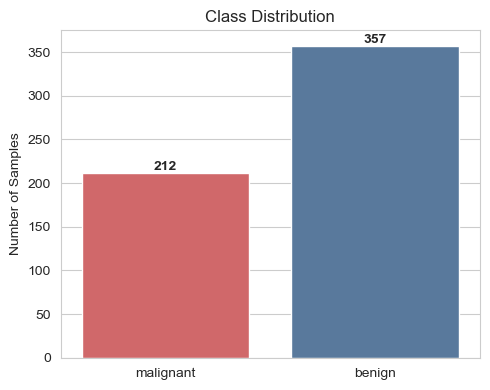

In [7]:
plt.figure(figsize=(5, 4))
sns.barplot(x=list(data.target_names), y=class_counts, palette=["#e15759", "#4e79a7"])
plt.title("Class Distribution")
plt.ylabel("Number of Samples")
for i, c in enumerate(class_counts):
    plt.text(i, c + 3, str(c), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


## 3. Train/Test Split & Feature Scaling

- 80/20 split, stratified on `y` so class proportions are preserved in both sets.
- Features are standardized (zero mean, unit variance) — this matters for Logistic Regression's optimizer and keeps Naive Bayes's per-feature Gaussian estimates well-behaved.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)


X_train: (455, 30)
X_test:  (114, 30)
y_train: (455,)
y_test:  (114,)


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Example of scaled training rows:")
print(X_train_scaled[:3])


Example of scaled training rows:
[[-1.072  -0.6584 -1.0881 -0.9393 -0.1359 -1.0087 -0.9684 -1.102   0.2811
  -0.1132 -0.7049 -0.4409 -0.7439 -0.6298  0.0007 -0.9916 -0.6938 -0.9833
  -0.5916 -0.429  -1.0341 -0.6235 -1.0708 -0.8765 -0.17   -1.0388 -1.079
  -1.3505 -0.3527 -0.5414]
 [ 1.7487  0.0665  1.7512  1.7456  1.2745  0.8423  1.5199  1.9947 -0.293
  -0.3202  0.1276 -0.3814  0.0941  0.3175  0.6397  0.0874  0.7085  1.1822
   0.4262  0.0748  1.2283 -0.0928  1.1875  1.1044  1.517   0.2497  1.1786
   1.5499  0.1911 -0.1737]
 [-0.9747 -0.9311 -0.9977 -0.8676 -0.6135 -1.1382 -1.0923 -1.2434  0.4344
  -0.4292 -0.2544  1.2371 -0.3386 -0.4138  0.5202 -0.8331 -1.0067 -1.8579
   1.356  -1.0066 -0.9732 -1.0368 -1.008  -0.8342 -1.0978 -1.1673 -1.2822
  -1.7074 -0.3077 -1.213 ]]


## 4. Model 1 — Logistic Regression

### 4.1 Train the model

In [13]:
log_model = LogisticRegression(max_iter=10000)
log_model.fit(X_train_scaled, y_train)

print("Model trained.")
print("Number of coefficients:", log_model.coef_.shape[1])
print("Intercept:", log_model.intercept_[0])


Model trained.
Number of coefficients: 30
Intercept: 0.300511589066433


### 4.2 Predictions

In [15]:
y_pred_log = log_model.predict(X_test_scaled)

comparison_log = pd.DataFrame({"Actual": y_test, "Predicted": y_pred_log})
print(comparison_log.head(10))


   Actual  Predicted
0       0          0
1       1          1
2       0          0
3       1          1
4       0          0
5       1          1
6       1          1
7       0          0
8       0          0
9       0          0


### 4.3 Accuracy

In [17]:
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy: {accuracy_log:.4f} ({accuracy_log*100:.2f}%)")


Logistic Regression Accuracy: 0.9825 (98.25%)


### 4.4 Confusion Matrix

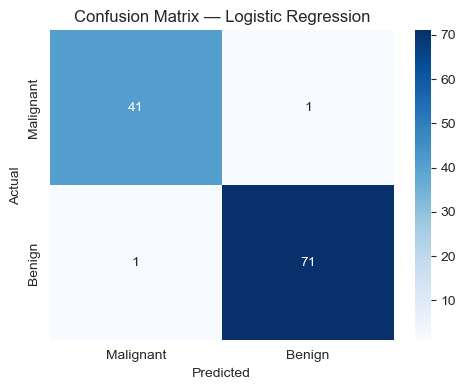

In [19]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_log, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()


### 4.5 Classification Report

In [21]:
print(classification_report(y_test, y_pred_log, target_names=["Malignant", "Benign"]))


              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### 4.6 Predicted Probabilities

In [23]:
y_prob_log = log_model.predict_proba(X_test_scaled)

results_log = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_log,
    "Malignant_Probability": y_prob_log[:, 0],
    "Benign_Probability": y_prob_log[:, 1]
})
print(results_log.head(10))


   Actual  Predicted  Malignant_Probability  Benign_Probability
0       0          0             1.0000e+00          6.0050e-08
1       1          1             1.1472e-05          9.9999e-01
2       0          0             9.9359e-01          6.4111e-03
3       1          1             4.6426e-01          5.3574e-01
4       0          0             1.0000e+00          6.6869e-10
5       1          1             7.9593e-03          9.9204e-01
6       1          1             1.7631e-05          9.9998e-01
7       0          0             1.0000e+00          5.8301e-07
8       0          0             9.9995e-01          5.4904e-05
9       0          0             1.0000e+00          8.1273e-11


### 4.7 Feature Importance (Model Coefficients)

In [25]:
coef_log = log_model.coef_[0]

feat_importance_log = pd.DataFrame({
    "Feature": data.feature_names,
    "Coefficient": coef_log
})
feat_importance_log["Abs_Coefficient"] = feat_importance_log["Coefficient"].abs()

top10_log = feat_importance_log.sort_values("Abs_Coefficient", ascending=False).head(10)
print(top10_log[["Feature", "Coefficient"]])


                 Feature  Coefficient
21         worst texture      -1.2483
10          radius error      -1.0843
23            worst area      -0.9537
27  worst concave points      -0.9485
20          worst radius      -0.9451
28        worst symmetry      -0.9352
13            area error      -0.9349
26       worst concavity      -0.8289
22       worst perimeter      -0.7614
24      worst smoothness      -0.7530


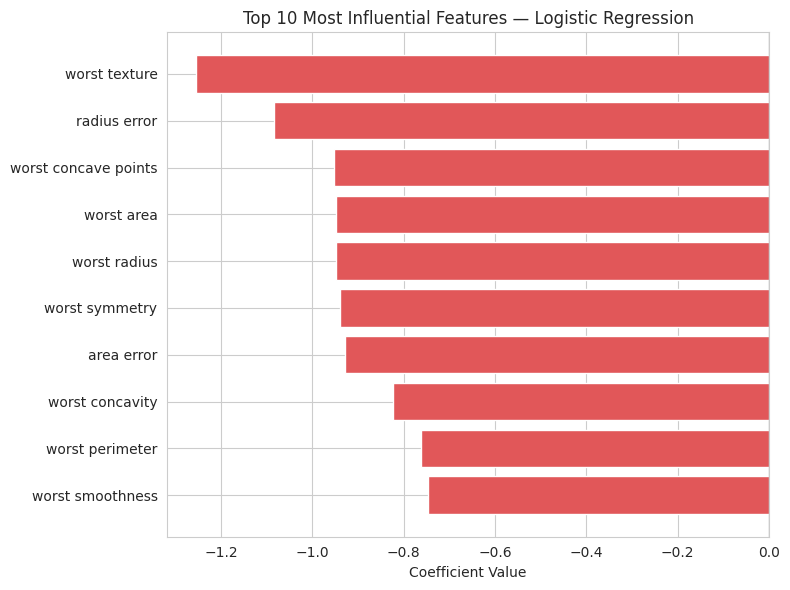

In [14]:
plt.figure(figsize=(8, 6))
colors = ["#e15759" if c < 0 else "#4e79a7" for c in top10_log["Coefficient"]]
plt.barh(top10_log["Feature"], top10_log["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient Value")
plt.title("Top 10 Most Influential Features — Logistic Regression")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### 4.8 Model Equation (Intercept + Coefficients)

In [27]:
print("Intercept:", log_model.intercept_[0])
print()
for feature, coef in zip(data.feature_names, log_model.coef_[0]):
    print(f"{feature:<25}: {coef: .6f}")


Intercept: 0.300511589066433

mean radius              : -0.505070
mean texture             : -0.558734
mean perimeter           : -0.471408
mean area                : -0.538737
mean smoothness          : -0.207718
mean compactness         :  0.653627
mean concavity           : -0.606579
mean concave points      : -0.700013
mean symmetry            : -0.172986
mean fractal dimension   :  0.193609
radius error             : -1.084279
texture error            :  0.251148
perimeter error          : -0.537215
area error               : -0.934894
smoothness error         : -0.158133
compactness error        :  0.642724
concavity error          :  0.171287
concave points error     : -0.447084
symmetry error           :  0.358784
fractal dimension error  :  0.435616
worst radius             : -0.945125
worst texture            : -1.248332
worst perimeter          : -0.761424
worst area               : -0.953706
worst smoothness         : -0.752978
worst compactness        :  0.043814
worst co

## 5. Model 2 — Gaussian Naive Bayes

### 5.1 Train the model

In [29]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

print("Model trained.")


Model trained.


### 5.2 Predictions

In [31]:
y_pred_nb = nb_model.predict(X_test_scaled)

comparison_nb = pd.DataFrame({"Actual": y_test, "Predicted": y_pred_nb})
print(comparison_nb.head(10))


   Actual  Predicted
0       0          0
1       1          1
2       0          0
3       1          1
4       0          0
5       1          1
6       1          1
7       0          0
8       0          0
9       0          0


### 5.3 Accuracy

In [33]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {accuracy_nb:.4f} ({accuracy_nb*100:.2f}%)")


Naive Bayes Accuracy: 0.9298 (92.98%)


### 5.4 Confusion Matrix

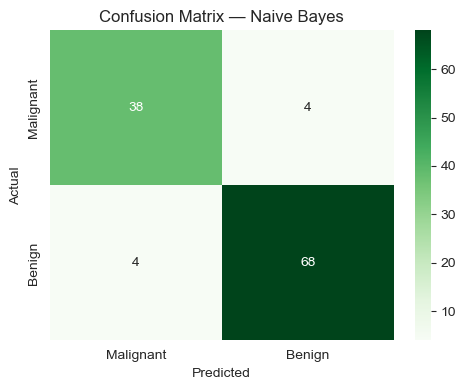

In [35]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_nb, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Naive Bayes")
plt.tight_layout()
plt.show()


### 5.5 Classification Report

In [37]:
print(classification_report(y_test, y_pred_nb, target_names=["Malignant", "Benign"]))


              precision    recall  f1-score   support

   Malignant       0.90      0.90      0.90        42
      Benign       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



### 5.6 Predicted Probabilities

In [39]:
y_prob_nb = nb_model.predict_proba(X_test_scaled)

results_nb = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_nb,
    "Malignant_Probability": y_prob_nb[:, 0],
    "Benign_Probability": y_prob_nb[:, 1]
})
print(results_nb.head(10))

# Sanity check: probabilities for each row sum to 1
print("\nProbabilities sum to 1:", np.allclose(y_prob_nb.sum(axis=1), 1))


   Actual  Predicted  Malignant_Probability  Benign_Probability
0       0          0             1.0000e+00          2.1751e-98
1       1          1             8.0034e-20          1.0000e+00
2       0          0             1.0000e+00          8.7371e-10
3       1          1             9.8423e-02          9.0158e-01
4       0          0             1.0000e+00         7.2481e-149
5       1          1             4.7692e-14          1.0000e+00
6       1          1             6.0927e-14          1.0000e+00
7       0          0             1.0000e+00          9.3529e-59
8       0          0             1.0000e+00          2.1481e-35
9       0          0             1.0000e+00         1.5438e-126

Probabilities sum to 1: True


### 5.7 Visualize Predicted Probabilities

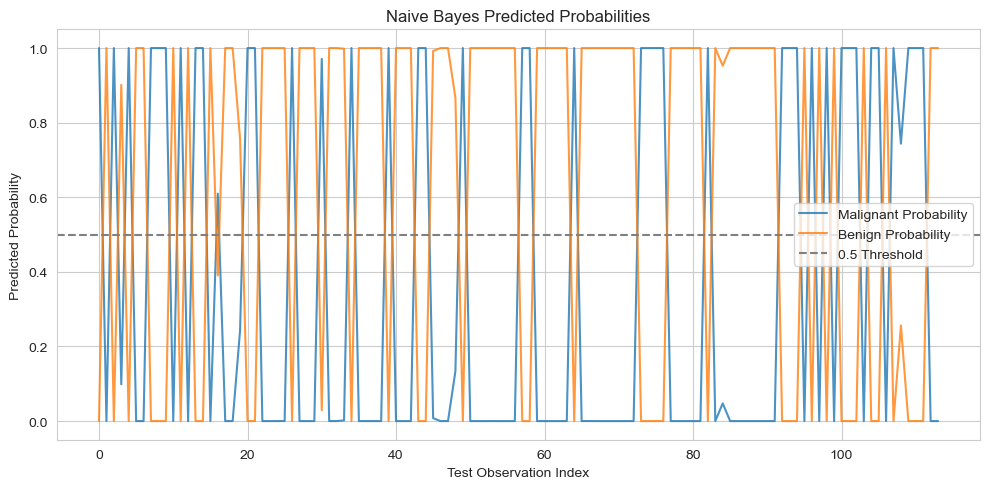

In [41]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(y_prob_nb)), y_prob_nb[:, 0], label="Malignant Probability", alpha=0.8)
plt.plot(range(len(y_prob_nb)), y_prob_nb[:, 1], label="Benign Probability", alpha=0.8)
plt.axhline(y=0.5, linestyle="--", color="gray", label="0.5 Threshold")
plt.xlabel("Test Observation Index")
plt.ylabel("Predicted Probability")
plt.title("Naive Bayes Predicted Probabilities")
plt.legend()
plt.tight_layout()
plt.show()


### 5.8 Correct vs. Incorrect Predictions

In [43]:
correct_nb = (y_test == y_pred_nb).sum()
incorrect_nb = (y_test != y_pred_nb).sum()

print("Correct predictions:  ", correct_nb)
print("Incorrect predictions:", incorrect_nb)


Correct predictions:   106
Incorrect predictions: 8


### 5.9 Feature Importance (Standardized Mean Difference)

In [45]:
# Effect-size style importance: how far apart are the class means,
# relative to their pooled standard deviation, for each feature.
mean_diff = nb_model.theta_[1] - nb_model.theta_[0]
avg_variance = (nb_model.var_[1] + nb_model.var_[0]) / 2
importance_nb = np.abs(mean_diff) / np.sqrt(avg_variance)

feat_importance_nb = pd.DataFrame({
    "Feature": data.feature_names,
    "Importance": importance_nb
}).sort_values("Importance", ascending=False)

top10_nb = feat_importance_nb.head(10)
print(top10_nb)


                 Feature  Importance
27  worst concave points      2.6322
22       worst perimeter      2.3842
7    mean concave points      2.3484
20          worst radius      2.3325
2         mean perimeter      2.1438
0            mean radius      2.0698
23            worst area      2.0030
3              mean area      1.8929
6         mean concavity      1.8608
26       worst concavity      1.7911


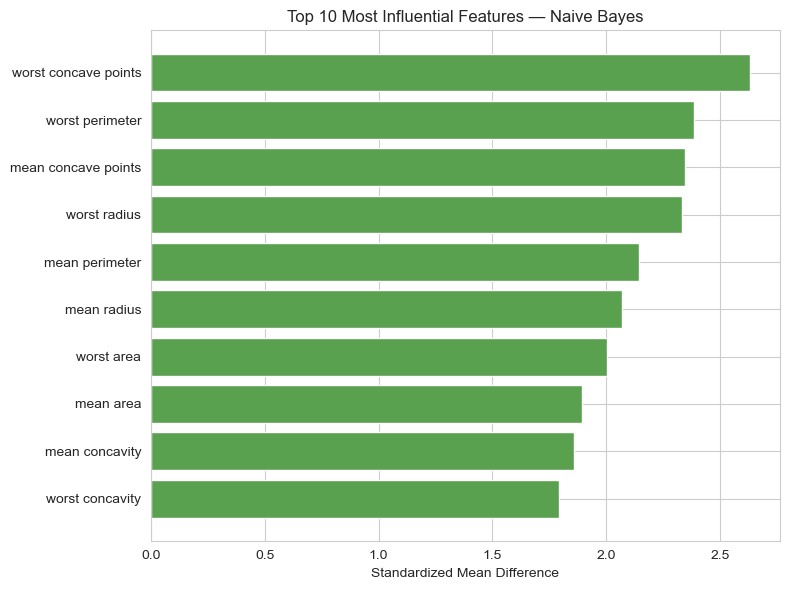

In [47]:
plt.figure(figsize=(8, 6))
plt.barh(top10_nb["Feature"], top10_nb["Importance"], color="#59a14f")
plt.xlabel("Standardized Mean Difference")
plt.title("Top 10 Most Influential Features — Naive Bayes")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 6. Model Comparison

### 6.1 Metric Summary Table

In [49]:
def get_metrics(y_true, y_pred, pos_label=1):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=pos_label),
        "Recall": recall_score(y_true, y_pred, pos_label=pos_label),
        "F1-score": f1_score(y_true, y_pred, pos_label=pos_label),
    }

metrics_log = get_metrics(y_test, y_pred_log)
metrics_nb = get_metrics(y_test, y_pred_nb)

comparison_table = pd.DataFrame({
    "Logistic Regression": metrics_log,
    "Naive Bayes": metrics_nb
}).T

print(comparison_table)


                     Accuracy  Precision  Recall  F1-score
Logistic Regression    0.9825     0.9861  0.9861    0.9861
Naive Bayes            0.9298     0.9444  0.9444    0.9444


### 6.2 Metric Comparison Chart

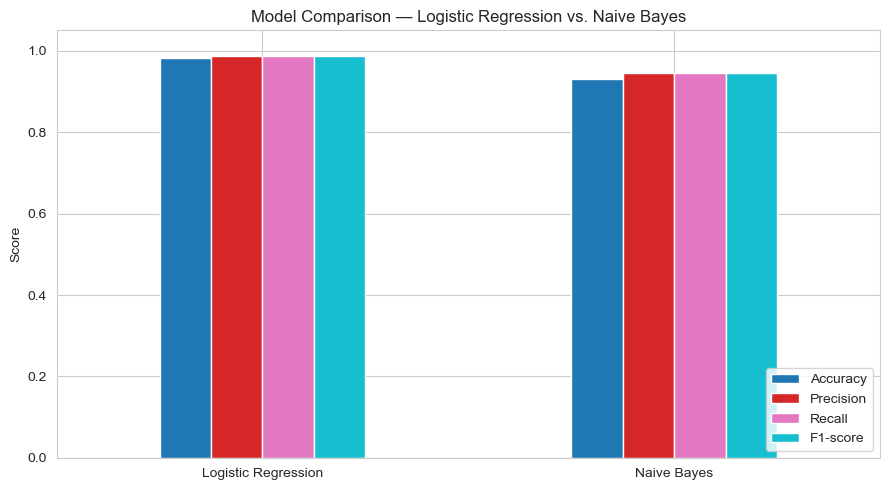

In [51]:
comparison_table.plot(kind="bar", figsize=(9, 5), colormap="tab10", rot=0)
plt.title("Model Comparison — Logistic Regression vs. Naive Bayes")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 6.3 ROC Curves

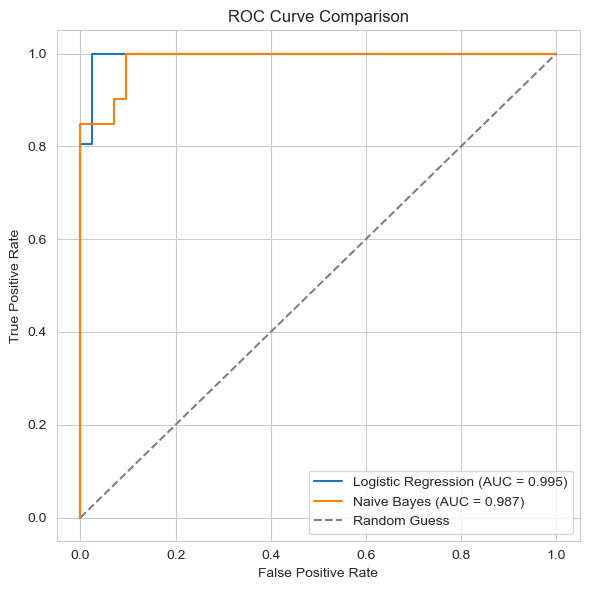

In [53]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log[:, 1])
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb[:, 1])

auc_log = roc_auc_score(y_test, y_prob_log[:, 1])
auc_nb = roc_auc_score(y_test, y_prob_nb[:, 1])

plt.figure(figsize=(6, 6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {auc_nb:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 6.4 Confusion Matrices Side-by-Side

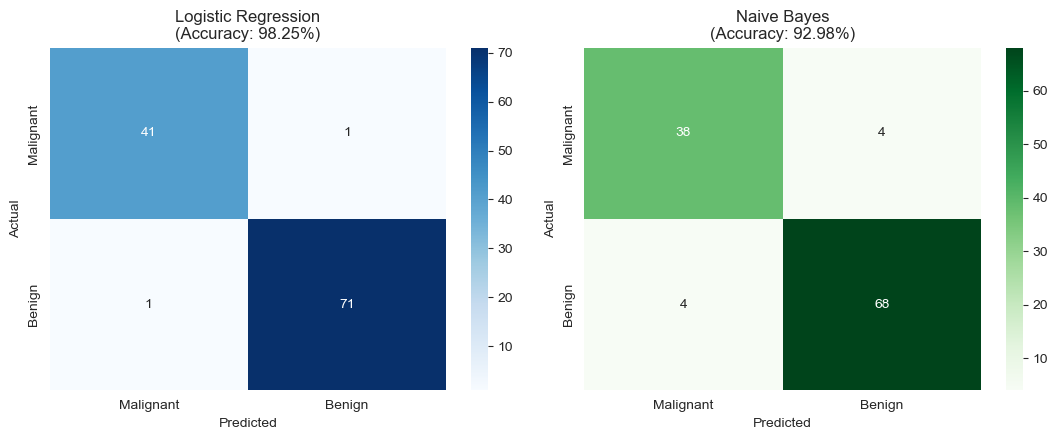

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Malignant", "Benign"], yticklabels=["Malignant", "Benign"])
axes[0].set_title(f"Logistic Regression\n(Accuracy: {accuracy_log*100:.2f}%)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=["Malignant", "Benign"], yticklabels=["Malignant", "Benign"])
axes[1].set_title(f"Naive Bayes\n(Accuracy: {accuracy_nb*100:.2f}%)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


## 7. Conclusion

- **Logistic Regression** and **Naive Bayes** were both trained on an 80/20 stratified split of the Breast Cancer Wisconsin dataset, using standardized features.
- The metric table and ROC curves above make it possible to compare the two models directly on accuracy, precision, recall, F1-score, and AUC.
- Logistic Regression's feature importance comes from its learned coefficients; Naive Bayes's comes from the standardized difference between class means, so the two "most important feature" lists are not directly comparable in scale, but both highlight which measurements separate malignant from benign tumors most strongly.
- In general, Logistic Regression tends to edge out Naive Bayes on this dataset because it doesn't assume feature independence — but re-run the cells above to see the exact numbers for this split.


